In [4]:
# Libraries for PCA analysis
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

In [5]:

# Update the path if your data file is in a different location
file_path = r'C:\Users\themo\OneDrive\Desktop\Machine Learning\Project\monthly_average_BATS_cleaned.csv'
df = pd.read_csv(file_path)
df.head()

,year_month,depth,Temperature,Salinity,Oxygen_1,CO2,Alkalinity,NO3_plus_NO2,NO2,PO4,Silicate,POC,PON,TOC,Bact_Enum,year,CO2_rolling,Alkalinity_rolling
0,1992-01-01,690.000000,15.565125,35.958723,225.854167,2056.258333,2398.263636,8.589375,0.083750,0.563542,8.352292,16.452188,3.523438,54.4,3.410000,1992,NaN,NaN
1,1992-02-01,585.584146,15.657915,35.998205,228.434091,2061.666667,2377.966667,8.487778,0.097381,0.556222,8.052222,13.292000,3.275000,54.4,3.951724,1992,NaN,NaN
2,1992-03-01,683.216667,15.043264,35.967208,227.029167,2062.550000,2392.100000,8.546596,0.036190,0.585745,8.768750,14.677188,3.524062,54.4,4.044444,1992,NaN,NaN
3,1992-04-01,606.393976,15.876349,36.027600,227.782222,2070.208333,2394.225000,8.256889,0.044889,0.525814,7.562000,19.444333,4.285667,54.4,4.230000,1992,NaN,NaN
4,1992-05-01,681.927778,15.662847,36.023271,228.402083,2068.016667,2392.408333,8.326667,0.008958,0.575000,7.776458,19.150000,4.015000,54.4,4.441667,1992,NaN,NaN


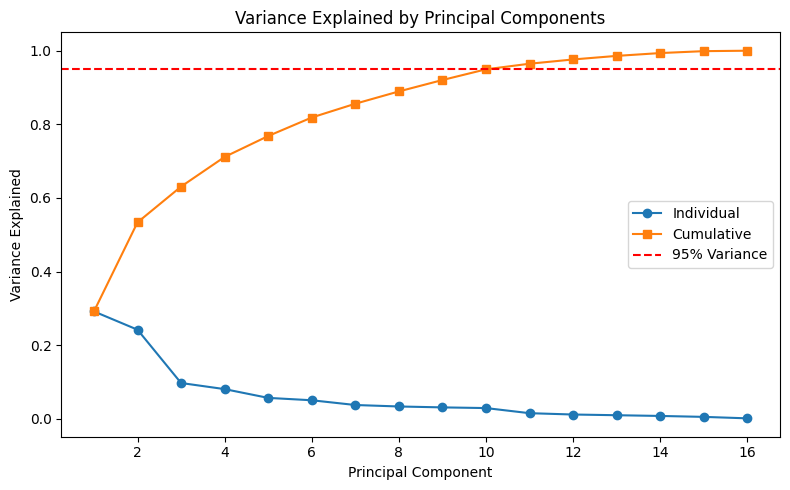

In [9]:
# Prepare data for PCA: remove 'year_month' and 'year' columns if present
X = df.drop(columns=[col for col in ['year_month', 'year'] if col in df.columns])
X = X.select_dtypes(include=[np.number])

# Remove rows with NaNs (safe for PCA)
X = X.dropna()

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance plot
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, marker='o', label='Individual')
plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), marker='s', label='Cumulative')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Variance')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained by Principal Components')
plt.legend()
plt.tight_layout()
plt.savefig('pca_variance_explained.png', dpi=150, bbox_inches='tight')
plt.show()

## Scatter Plot of First Two Principal Components
Visualize the data projected onto the first two principal components (PC1 and PC2). This helps reveal structure, clusters, or outliers in the reduced space.

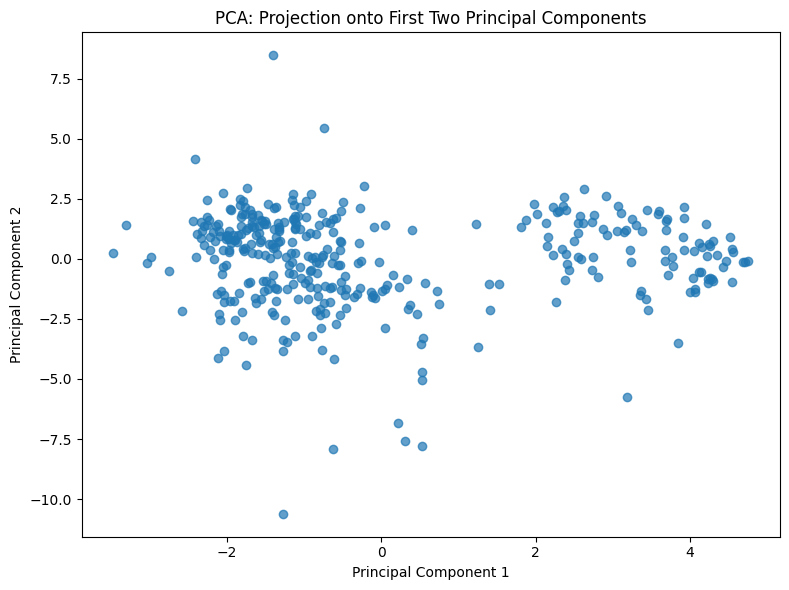

In [10]:
# Scatter plot of PC1 vs PC2
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Projection onto First Two Principal Components')
plt.tight_layout()
plt.savefig('pca_scatter_pc1_pc2.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpreting the PCA Scatter Plot
- **Each point** represents a sample from your dataset, projected onto the first two principal components (PC1 and PC2).
- **PC1 and PC2** are linear combinations of your original features that capture the most variance in the data.
- **Spread along PC1**: The horizontal axis (PC1) explains the largest amount of variance. Points far apart along this axis are most different in terms of the main variation in your data.
- **Spread along PC2**: The vertical axis (PC2) explains the second most variance, orthogonal to PC1.
- **Clusters or patterns**: If you see groups or trends, this suggests underlying structure in your data that PCA has revealed.
- **Outliers**: Points far from the main cloud may be outliers or unusual samples.

If you have labels or categories, you can color the points to see how groups separate in PCA space.

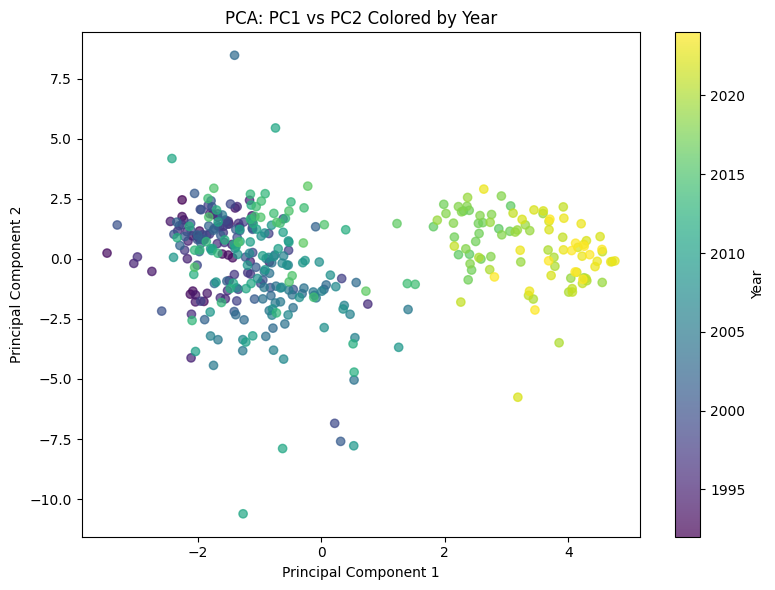

In [11]:
# Scatter plot of PC1 vs PC2 colored by year
# Get the year column, aligning with dropped NaNs
if 'year' in df.columns:
    years = df.loc[X.index, 'year']
else:
    years = None

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=years, cmap='viridis', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label('Year')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: PC1 vs PC2 Colored by Year')
plt.tight_layout()
plt.savefig('pca_scatter_pc1_pc2_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

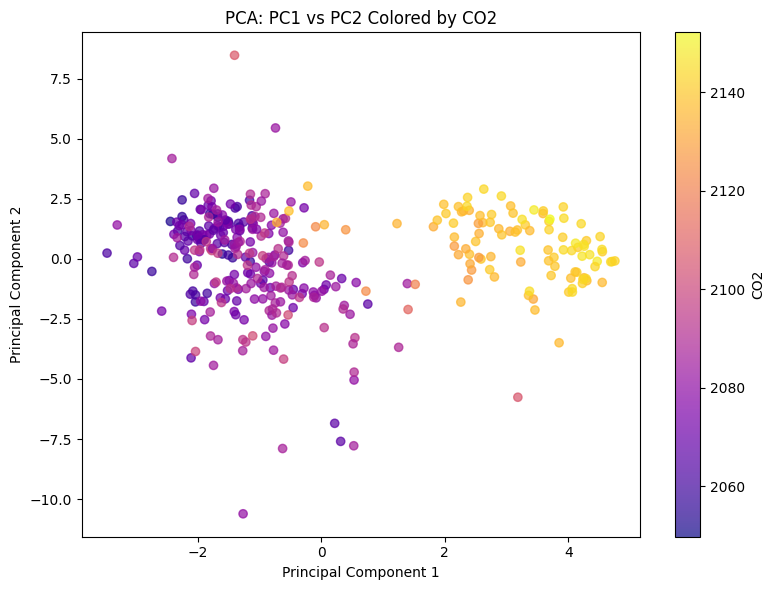

In [12]:
# Scatter plot of PC1 vs PC2 colored by CO2
# Get the CO2 column, aligning with dropped NaNs
if 'CO2' in df.columns:
    co2 = df.loc[X.index, 'CO2']
else:
    co2 = None

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=co2, cmap='plasma', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label('CO2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: PC1 vs PC2 Colored by CO2')
plt.tight_layout()
plt.savefig('pca_scatter_pc1_pc2_by_co2.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\themo\AppData\Local\Temp\ipykernel_27112\1704091603.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=depth, cmap='cividis', alpha=0.7)


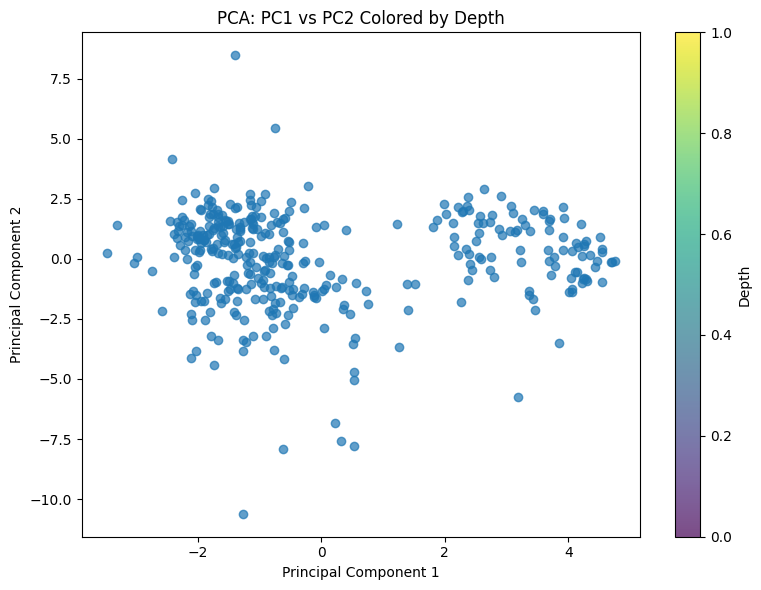

In [13]:
# Scatter plot of PC1 vs PC2 colored by Depth
# Get the Depth column, aligning with dropped NaNs
if 'Depth' in df.columns:
    depth = df.loc[X.index, 'Depth']
else:
    depth = None

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=depth, cmap='cividis', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label('Depth')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: PC1 vs PC2 Colored by Depth')
plt.tight_layout()
plt.savefig('pca_scatter_pc1_pc2_by_depth.png', dpi=150, bbox_inches='tight')
plt.show()

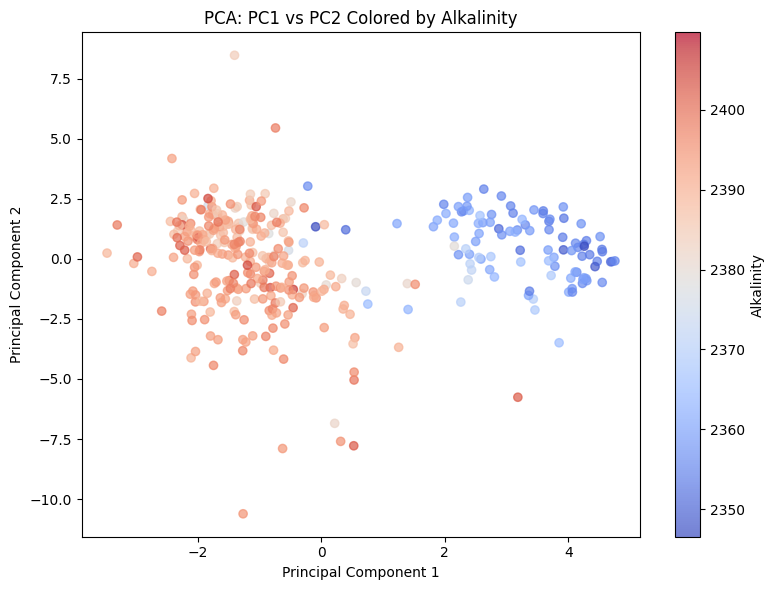

In [14]:
# Scatter plot of PC1 vs PC2 colored by Alkalinity
# Get the Alkalinity column, aligning with dropped NaNs
if 'Alkalinity' in df.columns:
    alkalinity = df.loc[X.index, 'Alkalinity']
else:
    alkalinity = None

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=alkalinity, cmap='coolwarm', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label('Alkalinity')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: PC1 vs PC2 Colored by Alkalinity')
plt.tight_layout()
plt.savefig('pca_scatter_pc1_pc2_by_alkalinity.png', dpi=150, bbox_inches='tight')
plt.show()